# Convolution - Splot

## Convolution using numpy

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib import style

In [5]:
x1 = np.array([1, 2, 2, 1, 1])
n1 = np.array([0, 1, 2, 3, 4])

x2 = np.array([3, 2, 1])
n2 = np.array([0, 1, 2])

nx1 = len(x1)  
nx2 = len(x2)
nconvol = nx1 + nx2 - 1

flippedX2 = x2[::-1]
half_nx2 = int(np.round(nx2/2))
data_4_convolution = np.concatenate((np.zeros(half_nx2), x1, np.zeros(half_nx2)), axis = 0 ) # adding zero ath the both sides of x1

# Convolution using for loop 
convres = np.zeros(nconvol)
for i in range (0, nconvol):
    convres[i] = np.sum(flippedX2 * data_4_convolution[i : i+nx2])

## Convolusion by np.convolve using mode = 'full' 

In [6]:
np.convolve(x1, x2, mode='full')


# The convolution operator is often seen in signal processing, where it
#  models the effect of a linear time-invariant system on a signal.  
# In probability theory, the sum of two independent random variables is
#  distributed according to the convolution of their individual distributions.

array([ 3,  8, 11,  9,  7,  3,  1])

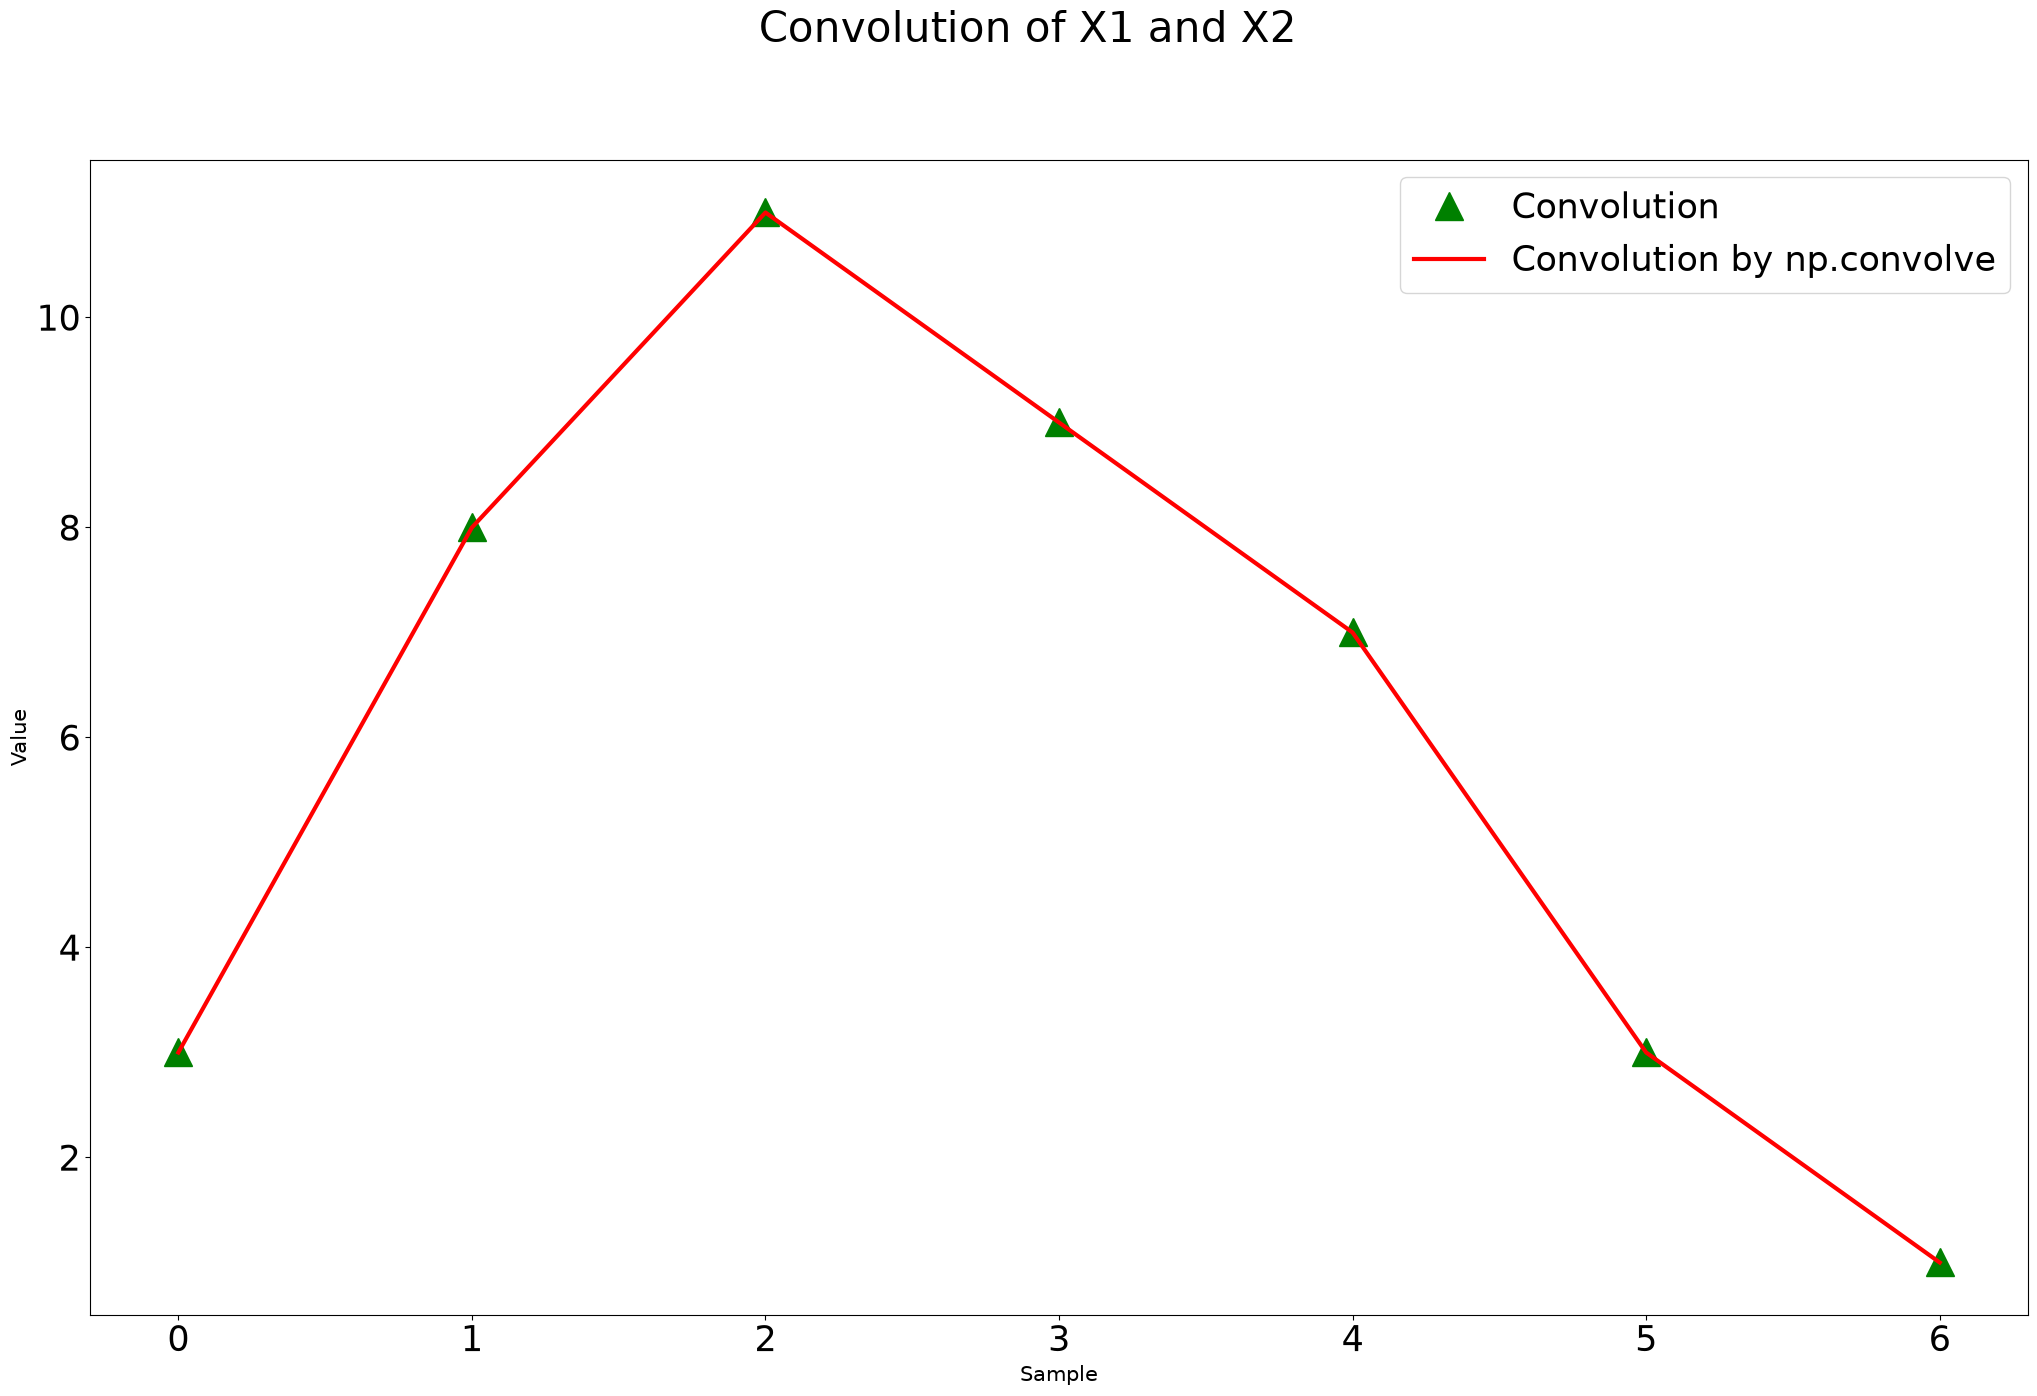

In [7]:
# Plotting Convolution - difference between np.convolution and for loop convolution (hardest way)

plt.figure(figsize=(25,15))
plt.suptitle("Convolution of X1 and X2", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(convres, 'g^', markersize=20, label="Convolution")
plt.plot(np.convolve(x1, x2, mode='full'), 'r-', linewidth=3, label='Convolution by np.convolve')
plt.xlabel('Sample', fontsize = 15)
plt.ylabel('Value', fontsize = 15)

plt.legend(fontsize = 25)
plt.show()





## Convolusion by np.convolve using mode = 'same'

In [8]:
np.convolve(x1, x2, mode='same')  # We use it when we have big amount of samples and we don't want to increase the number 

array([ 8, 11,  9,  7,  3])

In 'same' mode we get 5 samples instead of 7 like in  'full' mode. 

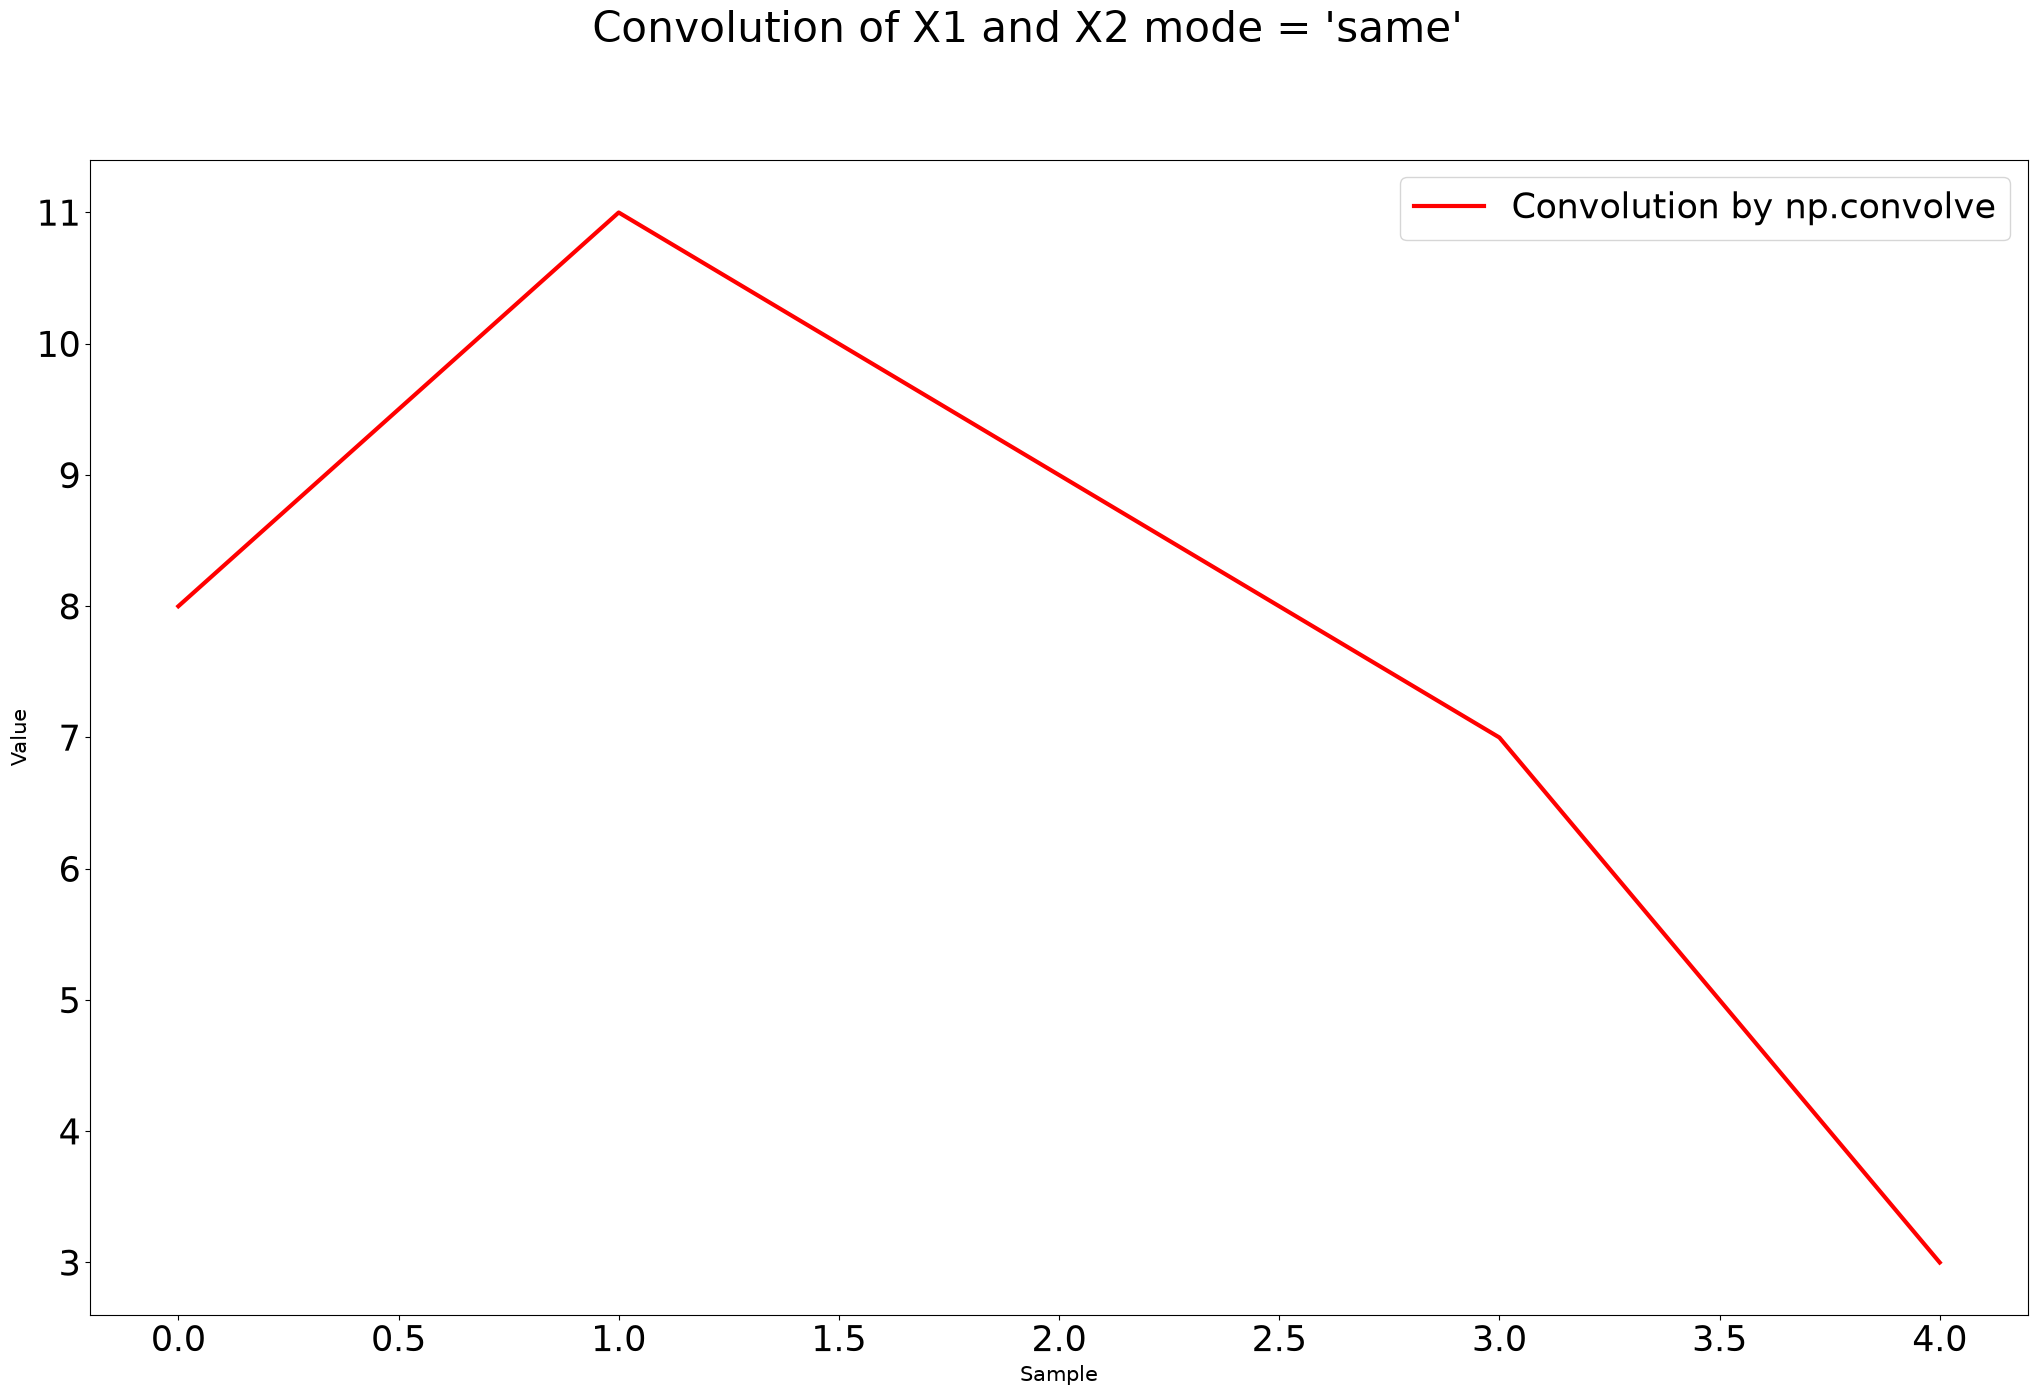

In [9]:
# Plotting Convolution - 'same' mode

plt.figure(figsize=(25,15))
plt.suptitle("Convolution of X1 and X2 mode = 'same'", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(np.convolve(x1, x2, mode='same'), 'r-', linewidth=3, label='Convolution by np.convolve')
plt.xlabel('Sample', fontsize = 15)
plt.ylabel('Value', fontsize = 15)

plt.legend(fontsize = 25)
plt.show()


# Aplications of Convolution

## 1. Denoising using convolution

For example we have a signal with the noise and we have to recover the original signal by removing the noise from it. 

So the denoising can also use convolution (splot) by selecting a suitable filter.

1. Select a suitable filter/kelner
2. Perform the convolution of that filter/kelner with the noisy signal to recover the original signal or to remove the noise. 

In [10]:
# creating a signal with noise (sygnał z szumem)
sampling_rate = 256 #Hz 
time = np.arange(0, 3, 1/sampling_rate) # Generating a time vector from 0 to 3
pnts = len(time) 

print(f"The number of samples between 0 and 3: {pnts}")

The number of samples between 0 and 3: 768


In [11]:
# Creating a noiseless signal (no noise)
signal = np.sin(2* np.pi * 2 * time)  # sinusoidal signal 

# Creating a noise
noise = 5 * np.random.randn(pnts)  # Gaussian noise

# Adding noise on signal
NoisySignal = signal + noise
print(f"Noisy Signal: {NoisySignal}")

Noisy Signal: [ 4.44964432e+00 -4.71273004e+00 -4.34499211e+00 -1.80023410e+00
  2.44587181e-01 -5.57518626e+00 -4.86734867e+00  2.24047333e+00
  8.82345007e-01  7.68767549e+00 -4.40423926e-01  5.71137379e+00
  2.16904286e-01 -1.20018970e+00 -3.77350392e+00  3.52298048e+00
 -4.95923867e+00  8.46832150e+00  2.81251667e+00  4.42744078e+00
  3.97266667e+00  3.19115829e+00 -1.90341306e+00  2.78803272e+00
 -3.93928328e-01  5.12768227e+00  3.29725532e+00  1.99959259e+01
 -7.63555715e-01  6.38798900e+00  5.11424094e-01 -1.32715137e+00
  2.94417001e+00 -1.91932438e+00  1.79134770e-01  6.80187615e+00
 -7.47363311e+00  7.90118694e-01  1.29879207e+00  3.56466612e+00
 -4.28473081e+00  8.40999241e+00  7.62818079e+00  6.34836469e+00
 -2.97481138e+00  9.01442021e+00  3.86201255e+00  2.00054706e+00
 -1.67655256e+00 -9.32359042e+00  2.21404079e-01 -2.20703846e+00
  1.01349151e+01  4.06463078e+00  5.43559421e+00  8.56042409e-01
 -8.97994558e+00  1.67052149e+00  5.24654581e-01  1.79997091e+00
 -5.5634125

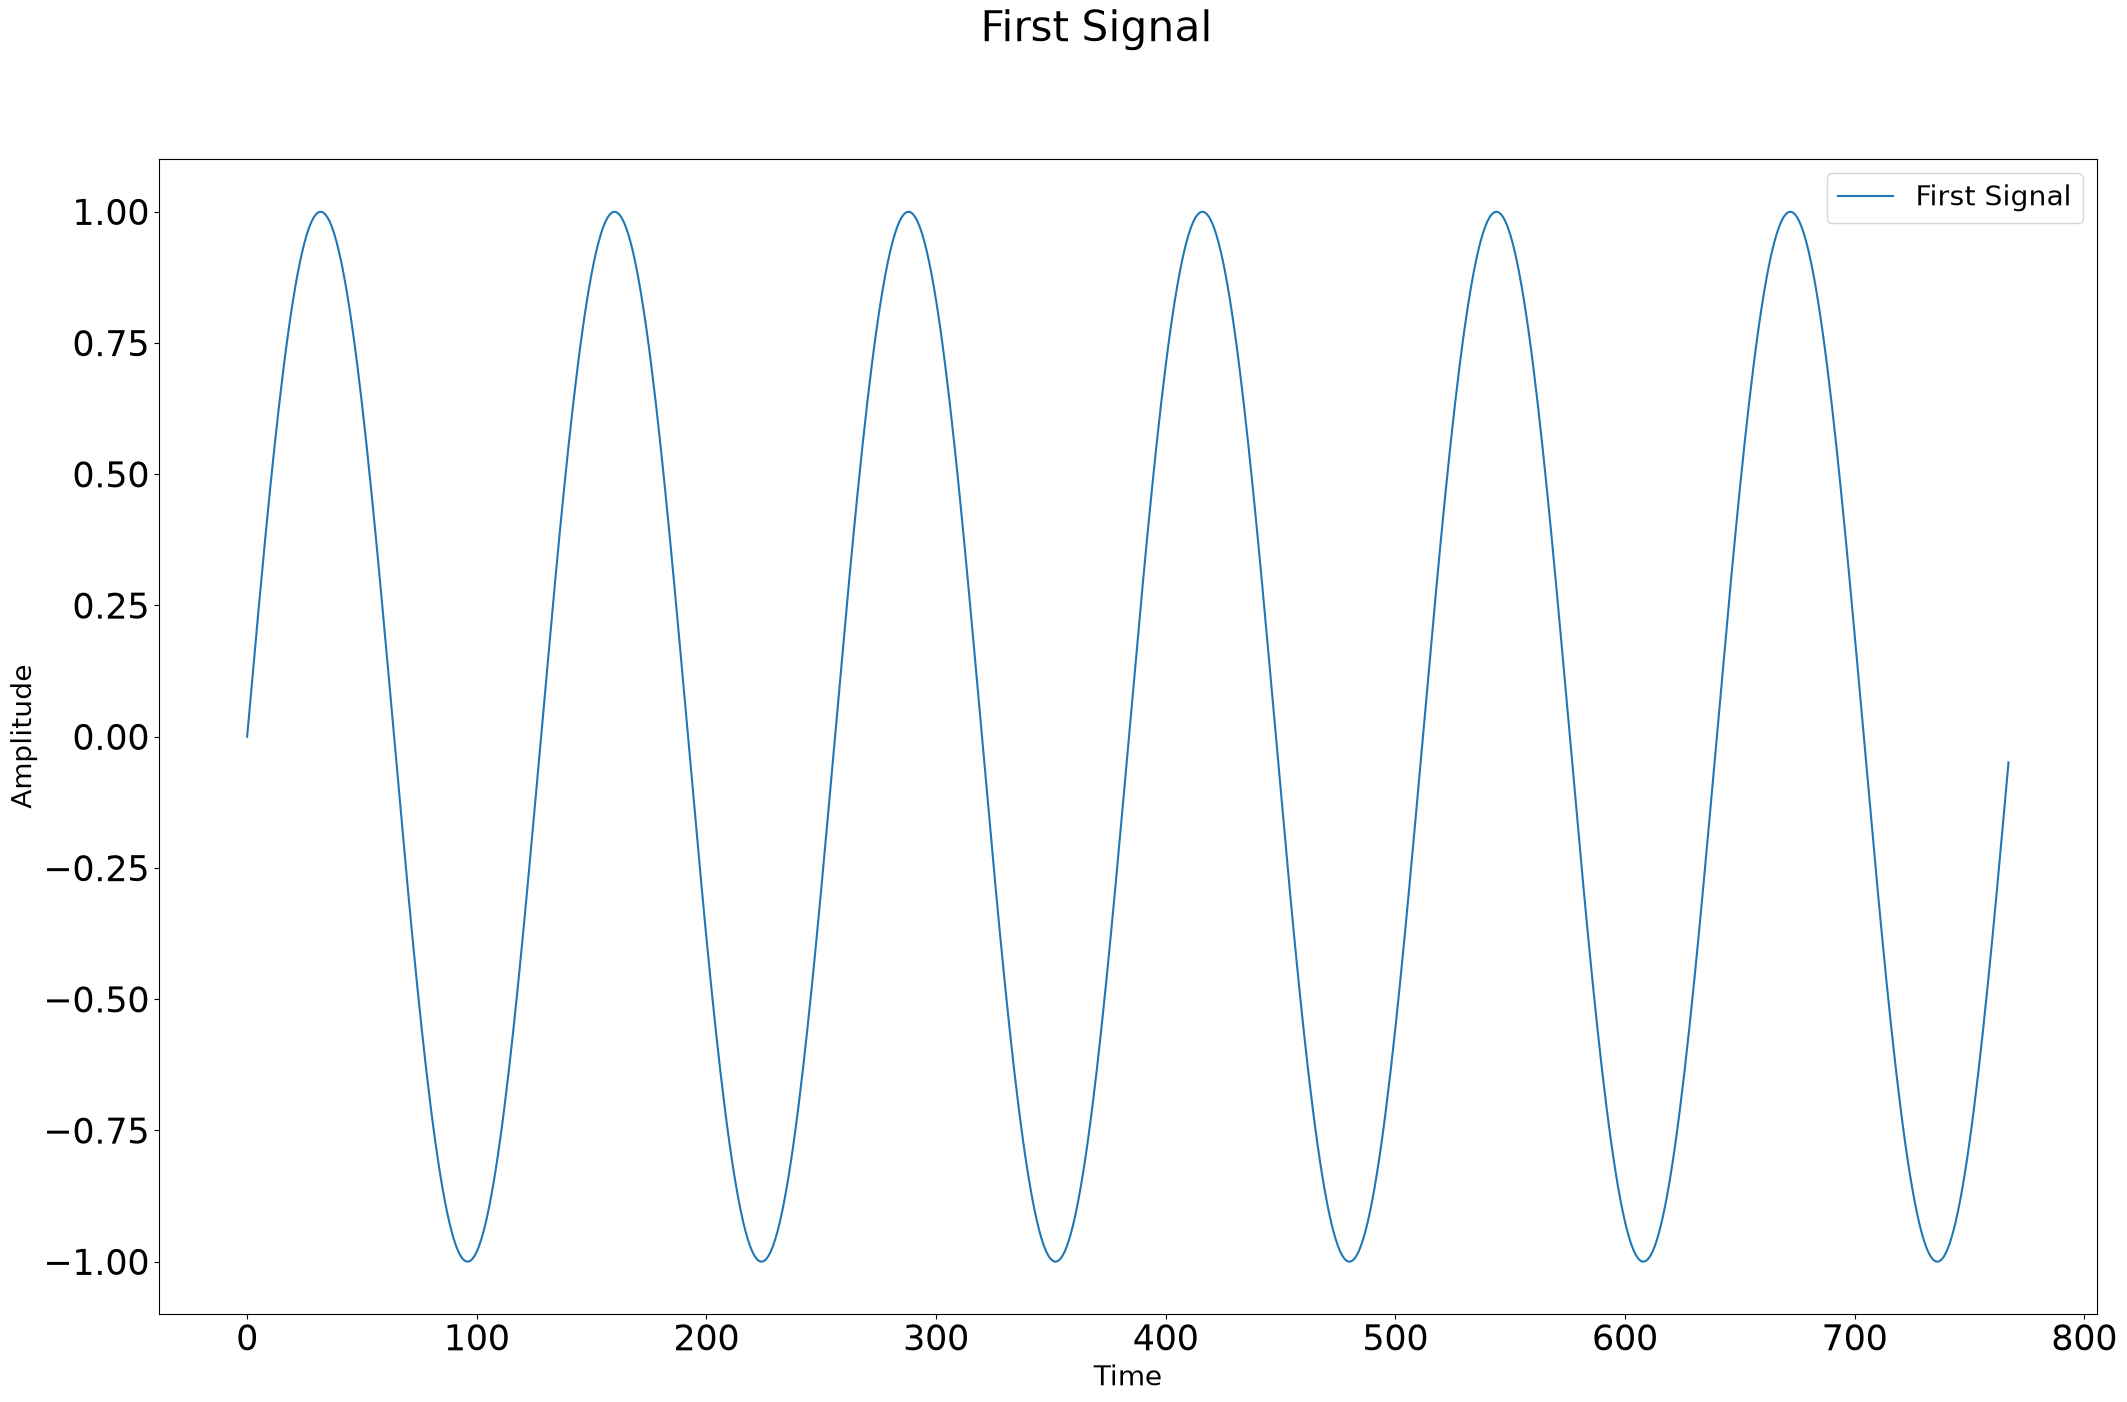

In [12]:
# Plotting signal without noise 

plt.figure(figsize=(25,15))
plt.suptitle("First Signal", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(signal, label='First Signal')
plt.xlabel('Time', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)

plt.legend(fontsize = 20)
plt.show()

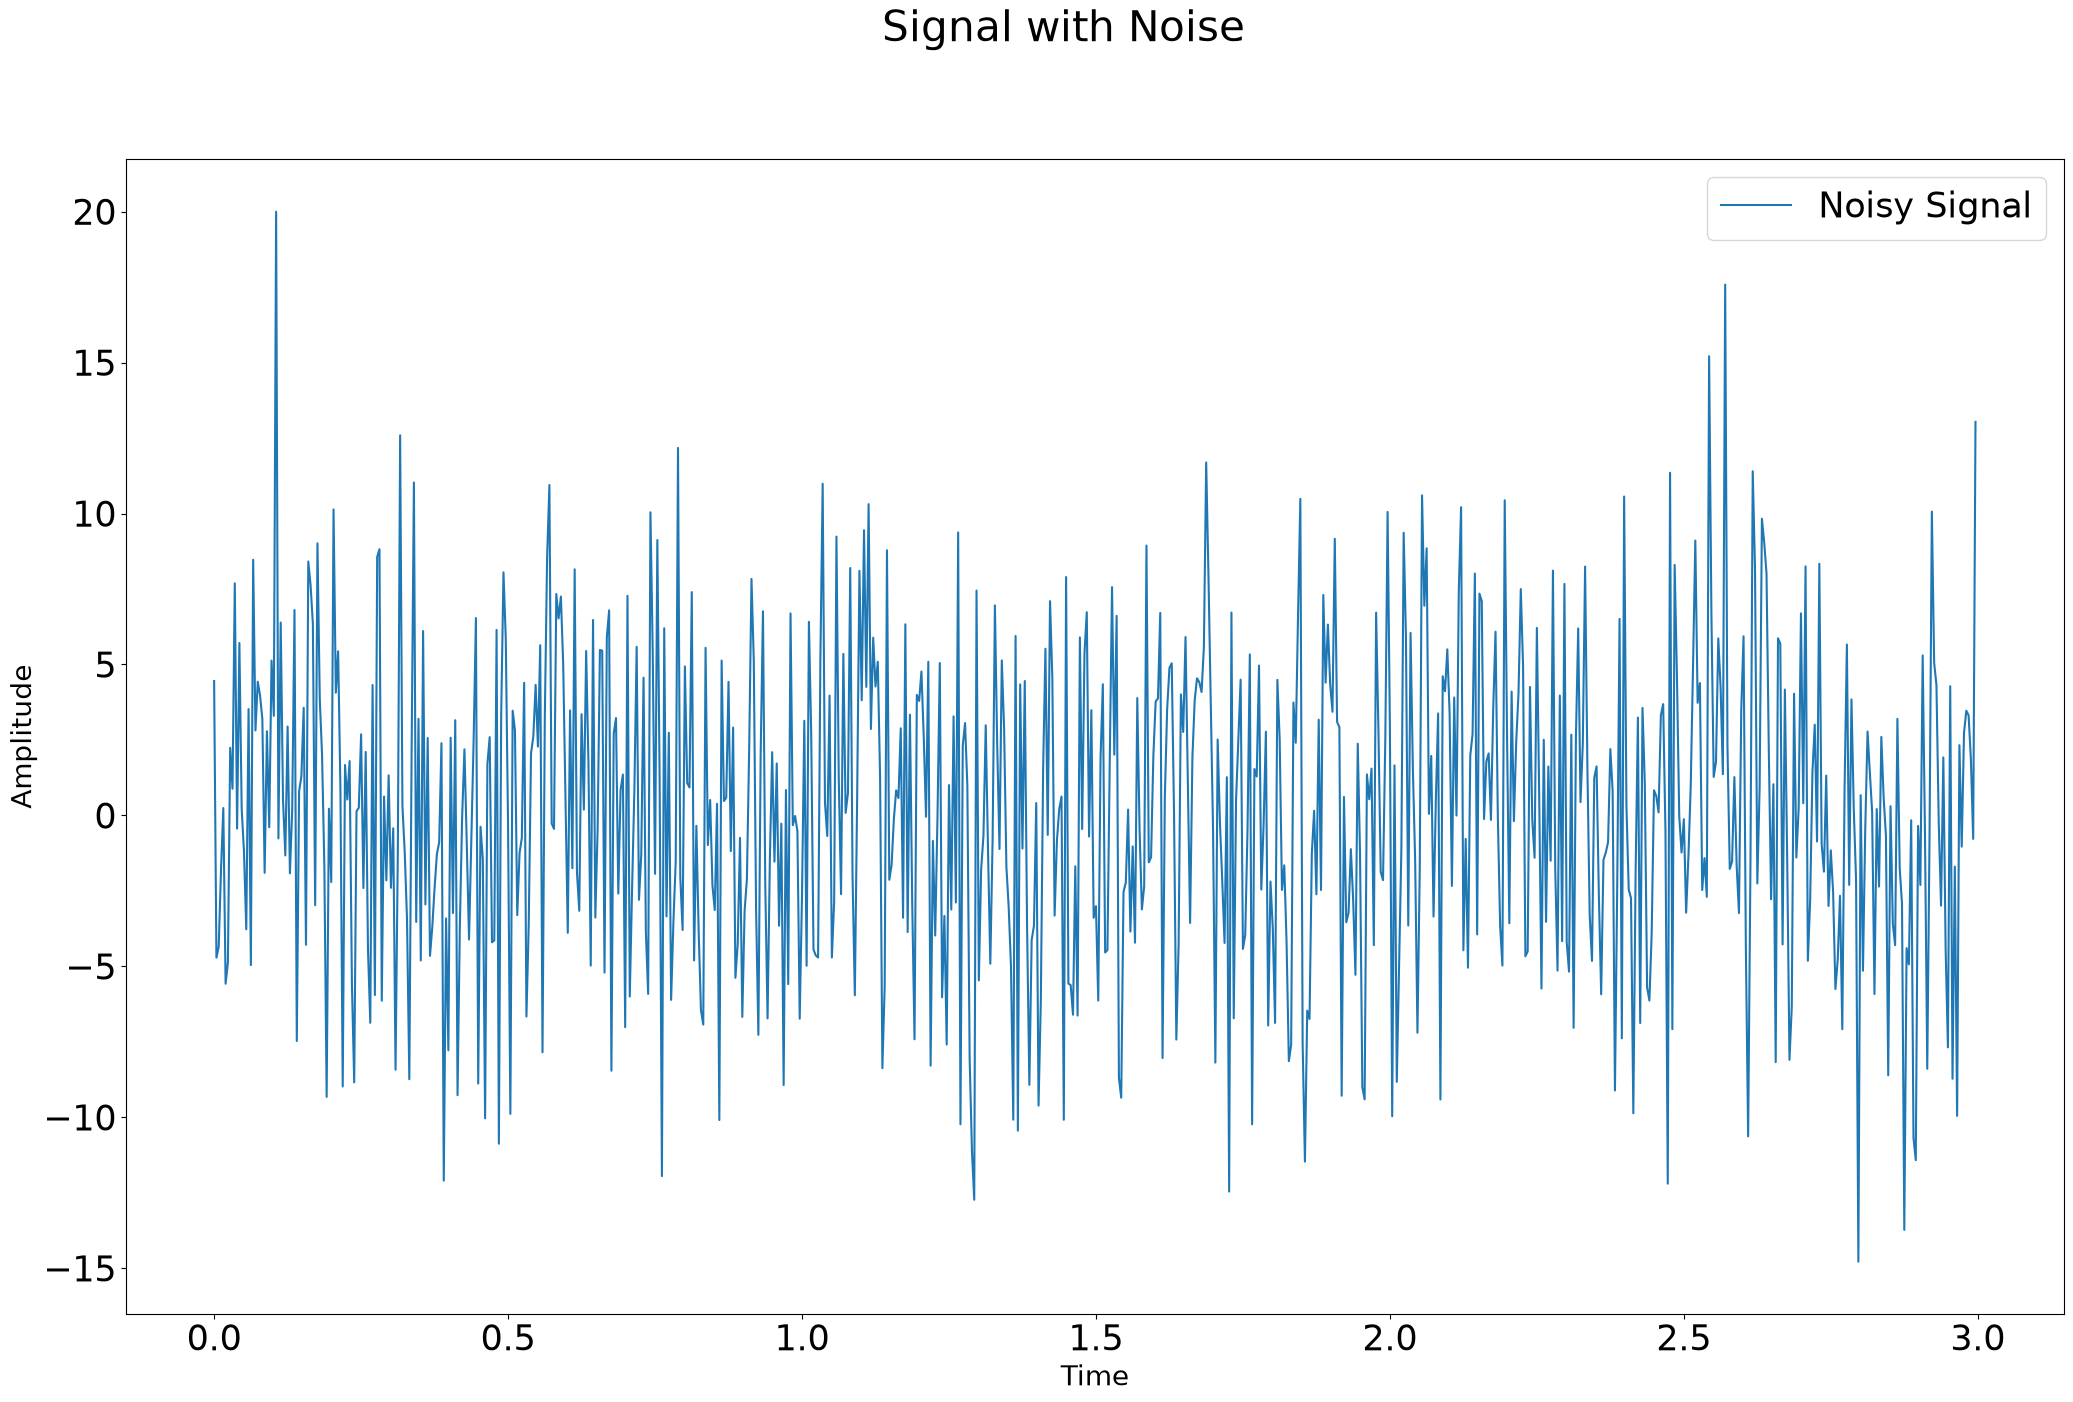

In [13]:
# Plotting noisy signal

plt.figure(figsize=(25,15))
plt.suptitle("Signal with Noise", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(time, NoisySignal, label='Noisy Signal')
plt.xlabel('Time', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)

plt.legend(fontsize = 25)
plt.show()


In [14]:
# Selecting filter for denosing 

filter = 2 * np.ones(50)/10  
filter

# it will move on the noisy signal and it will calculate the average value

array([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2])

In [15]:
# Filtering by convolution

filteredSignal = np.convolve(NoisySignal, filter, mode='same')
filteredSignal

array([ 3.32898635e+00,  4.35452280e+00,  5.01397386e+00,  9.01315904e+00,
        8.86044790e+00,  1.01380457e+01,  1.02403305e+01,  9.97490025e+00,
        1.05637342e+01,  1.01798694e+01,  1.02156963e+01,  1.15760716e+01,
        1.00813449e+01,  1.02393687e+01,  1.04991271e+01,  1.12120603e+01,
        1.03551141e+01,  1.20371126e+01,  1.35627488e+01,  1.48324217e+01,
        1.42374595e+01,  1.60403435e+01,  1.68127460e+01,  1.72128554e+01,
        1.68775449e+01,  1.50128268e+01,  1.41671788e+01,  1.46683171e+01,
        1.75642985e+01,  1.87372715e+01,  1.97754729e+01,  2.10617186e+01,
        2.02391993e+01,  2.01252089e+01,  2.00536708e+01,  1.88761299e+01,
        1.78515322e+01,  1.49406872e+01,  1.49241062e+01,  1.52153155e+01,
        1.65071622e+01,  1.53215238e+01,  1.67336516e+01,  1.41520057e+01,
        1.22155896e+01,  1.21939292e+01,  1.02091449e+01,  1.12829200e+01,
        1.34271246e+01,  1.16420293e+01,  1.18460016e+01,  1.03900398e+01,
        9.99604781e+00,  

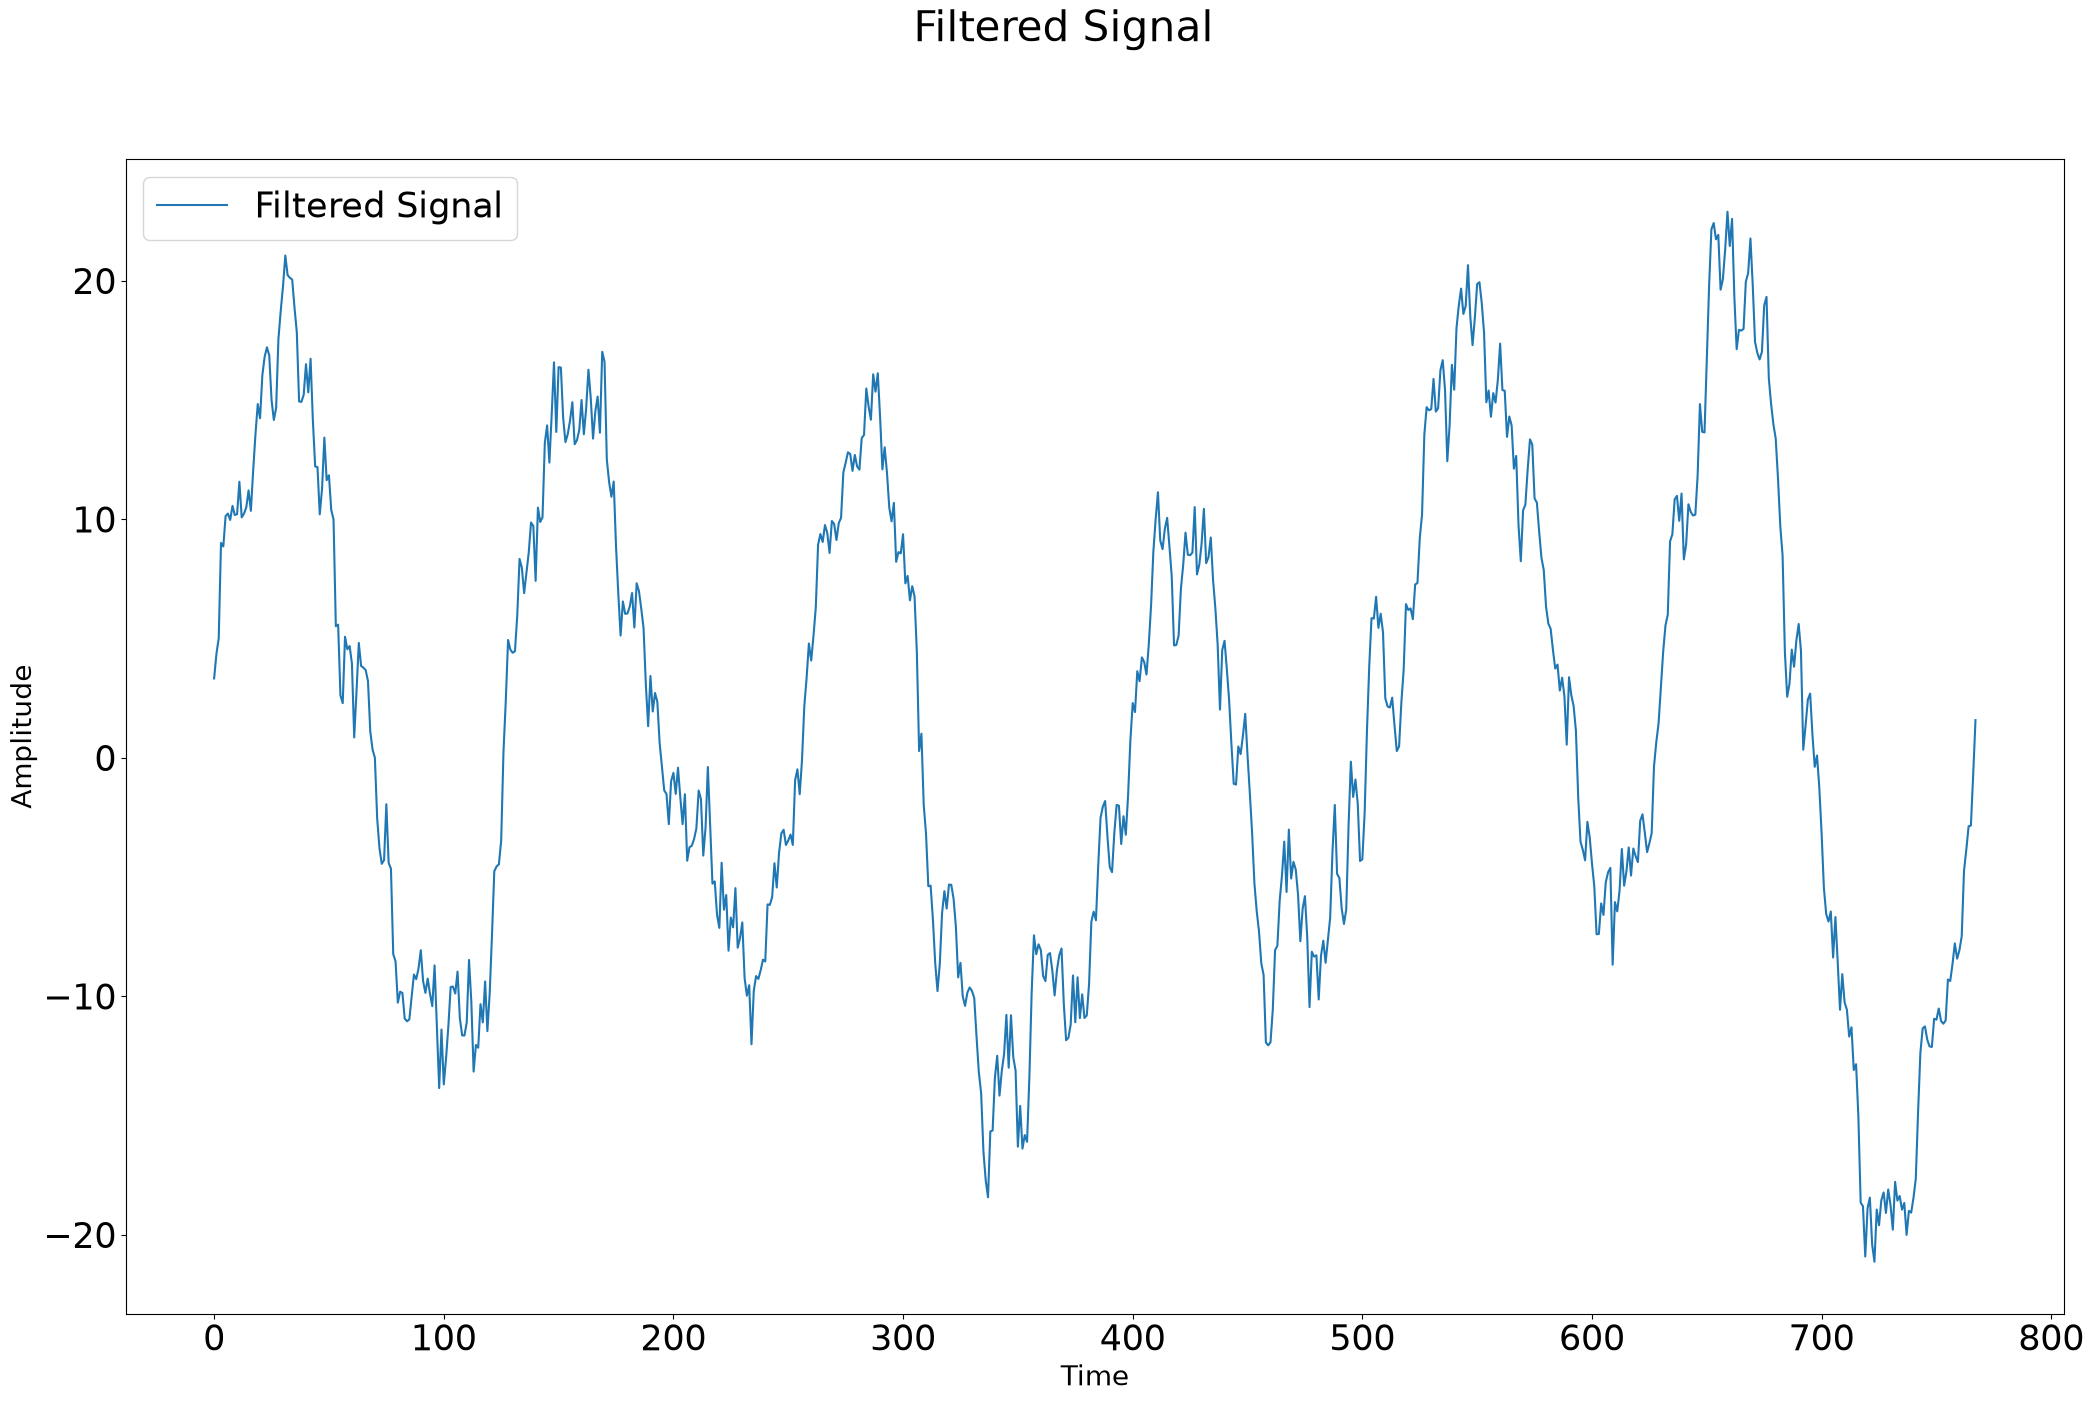

In [16]:
# Plotting filtered signal

plt.figure(figsize=(25,15))
plt.suptitle("Filtered Signal", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(filteredSignal, label='Filtered Signal')
plt.xlabel('Time', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)

plt.legend(fontsize = 25)
plt.show()


We have removed arounf 70-80% of noise using the convolution

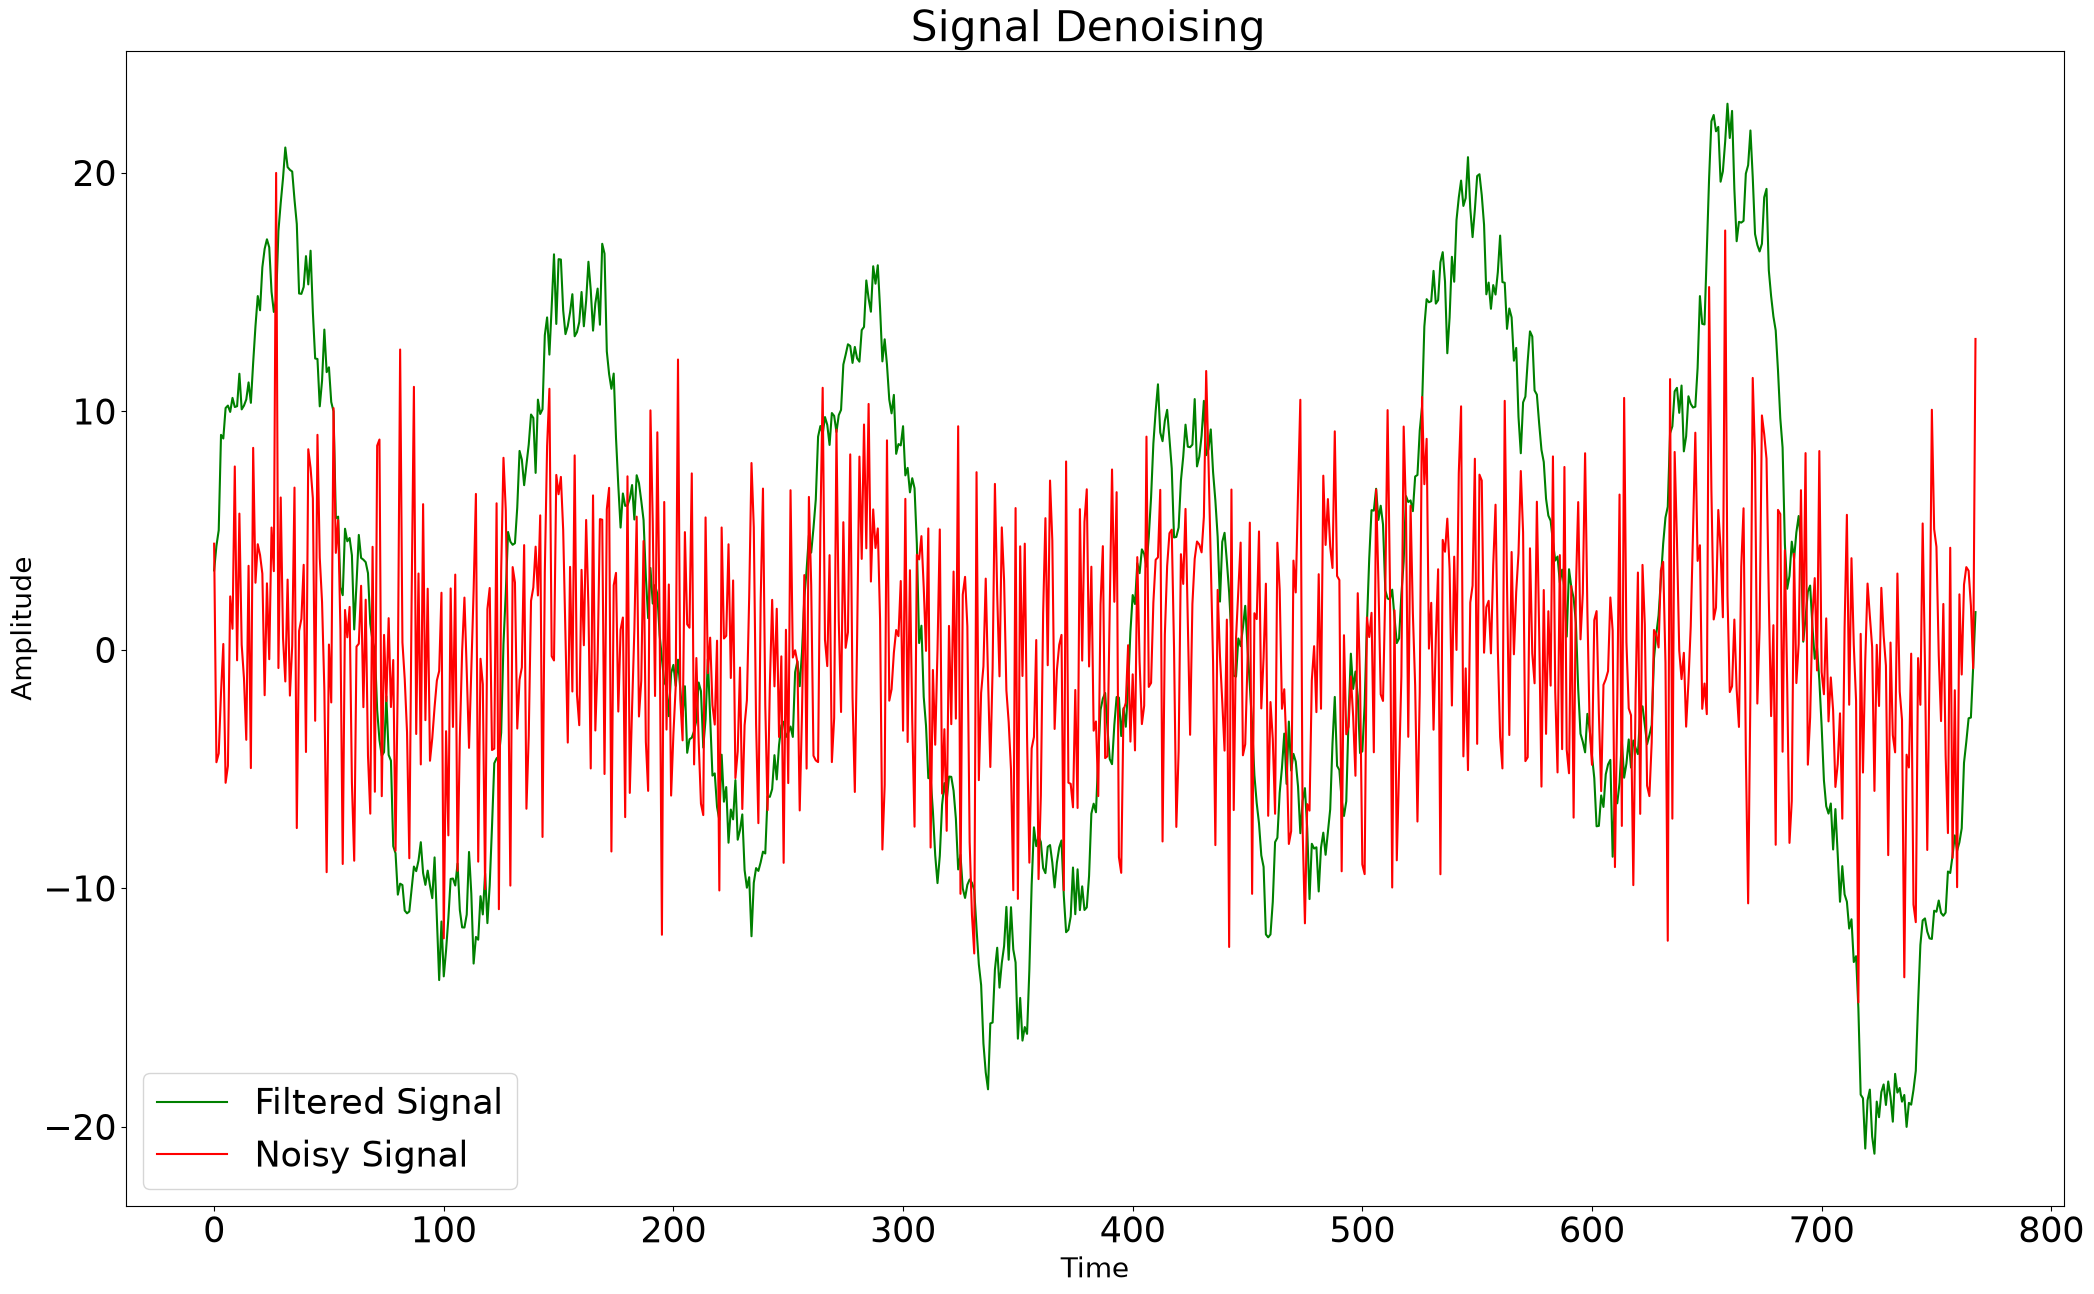

In [17]:
# Plotting noisy signal and filtered signal

plt.figure(figsize=(25,15))
plt.title("Signal Denoising ", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(filteredSignal, 'g', label='Filtered Signal')
plt.plot(NoisySignal, 'r', label='Noisy Signal')
plt.xlabel('Time', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)

plt.legend(fontsize = 25)
plt.show()

## 2. Edge Detection Using Convolution (Detekcja krawędzi z wykorzystaniem splotu)

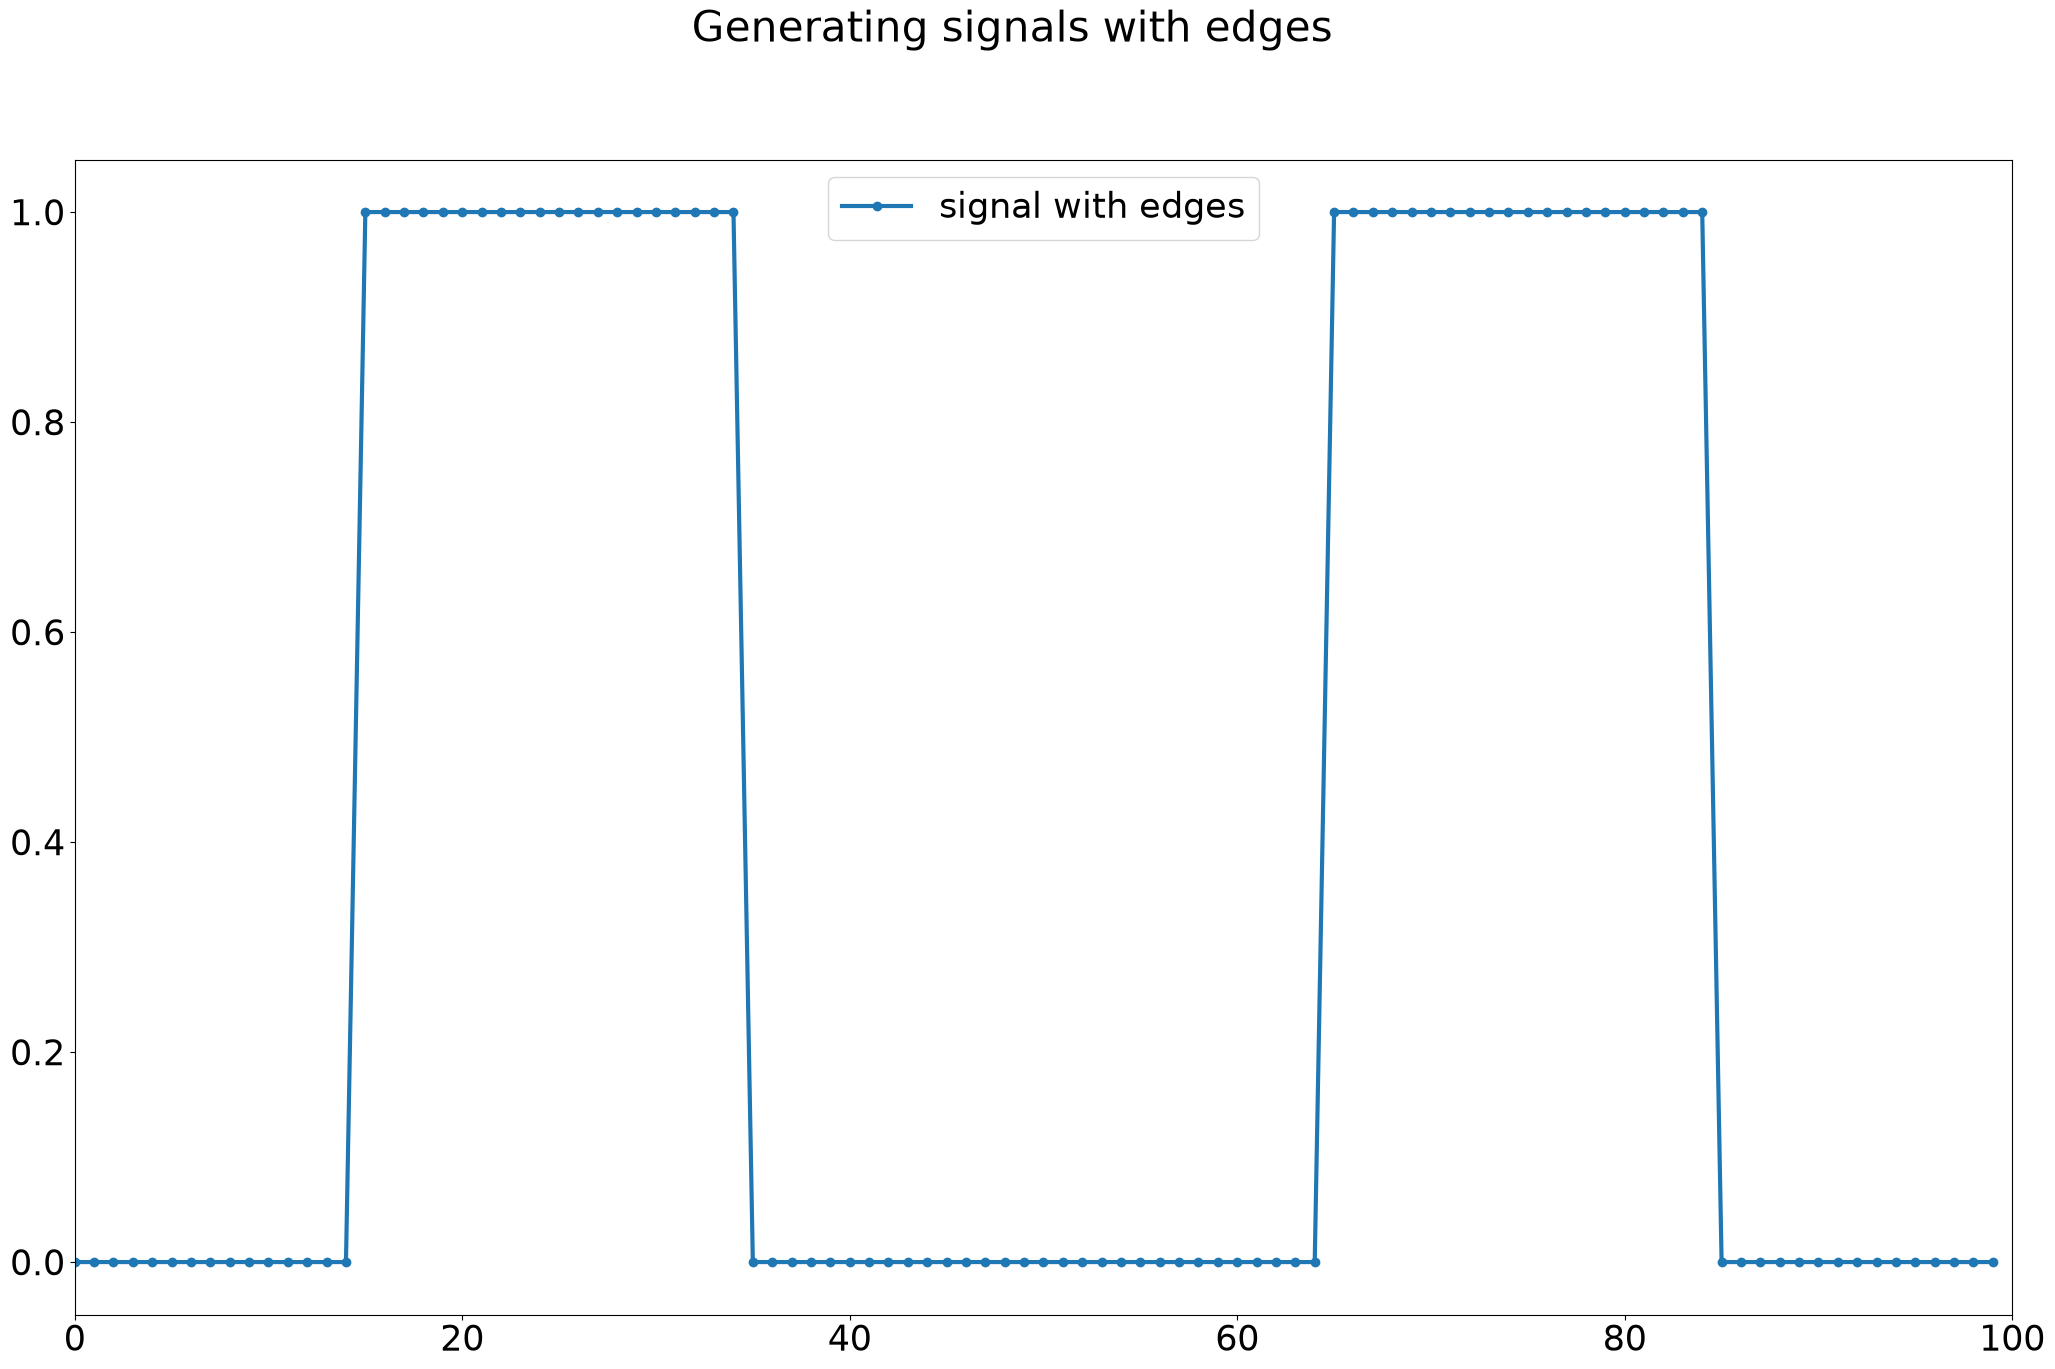

In [18]:
# Generating signals with edges

newSig = np.zeros(100)
newSig[15:35] = 1
newSig[65:85] = 1

# Plotting
plt.figure(figsize=(25,15))
plt.suptitle("Generating signals with edges", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.xlim(0,100)
plt.plot(newSig, 'o-', linewidth=3, label='signal with edges')

plt.legend(fontsize = 25)
plt.show()

In [21]:
# Kernel for edge detection 

# we have to select a suitable kernel
# we cannot use a moving avarage filter or moving average kernel, because the moving avarage kernel is used for denoising

# we using the kernel which has the ability to detect the edges  

kernel = np.array([0.5, 0.3, 0.1, 0, -0.1, -0.3, -0.5 ])
kernel

array([ 0.5,  0.3,  0.1,  0. , -0.1, -0.3, -0.5])

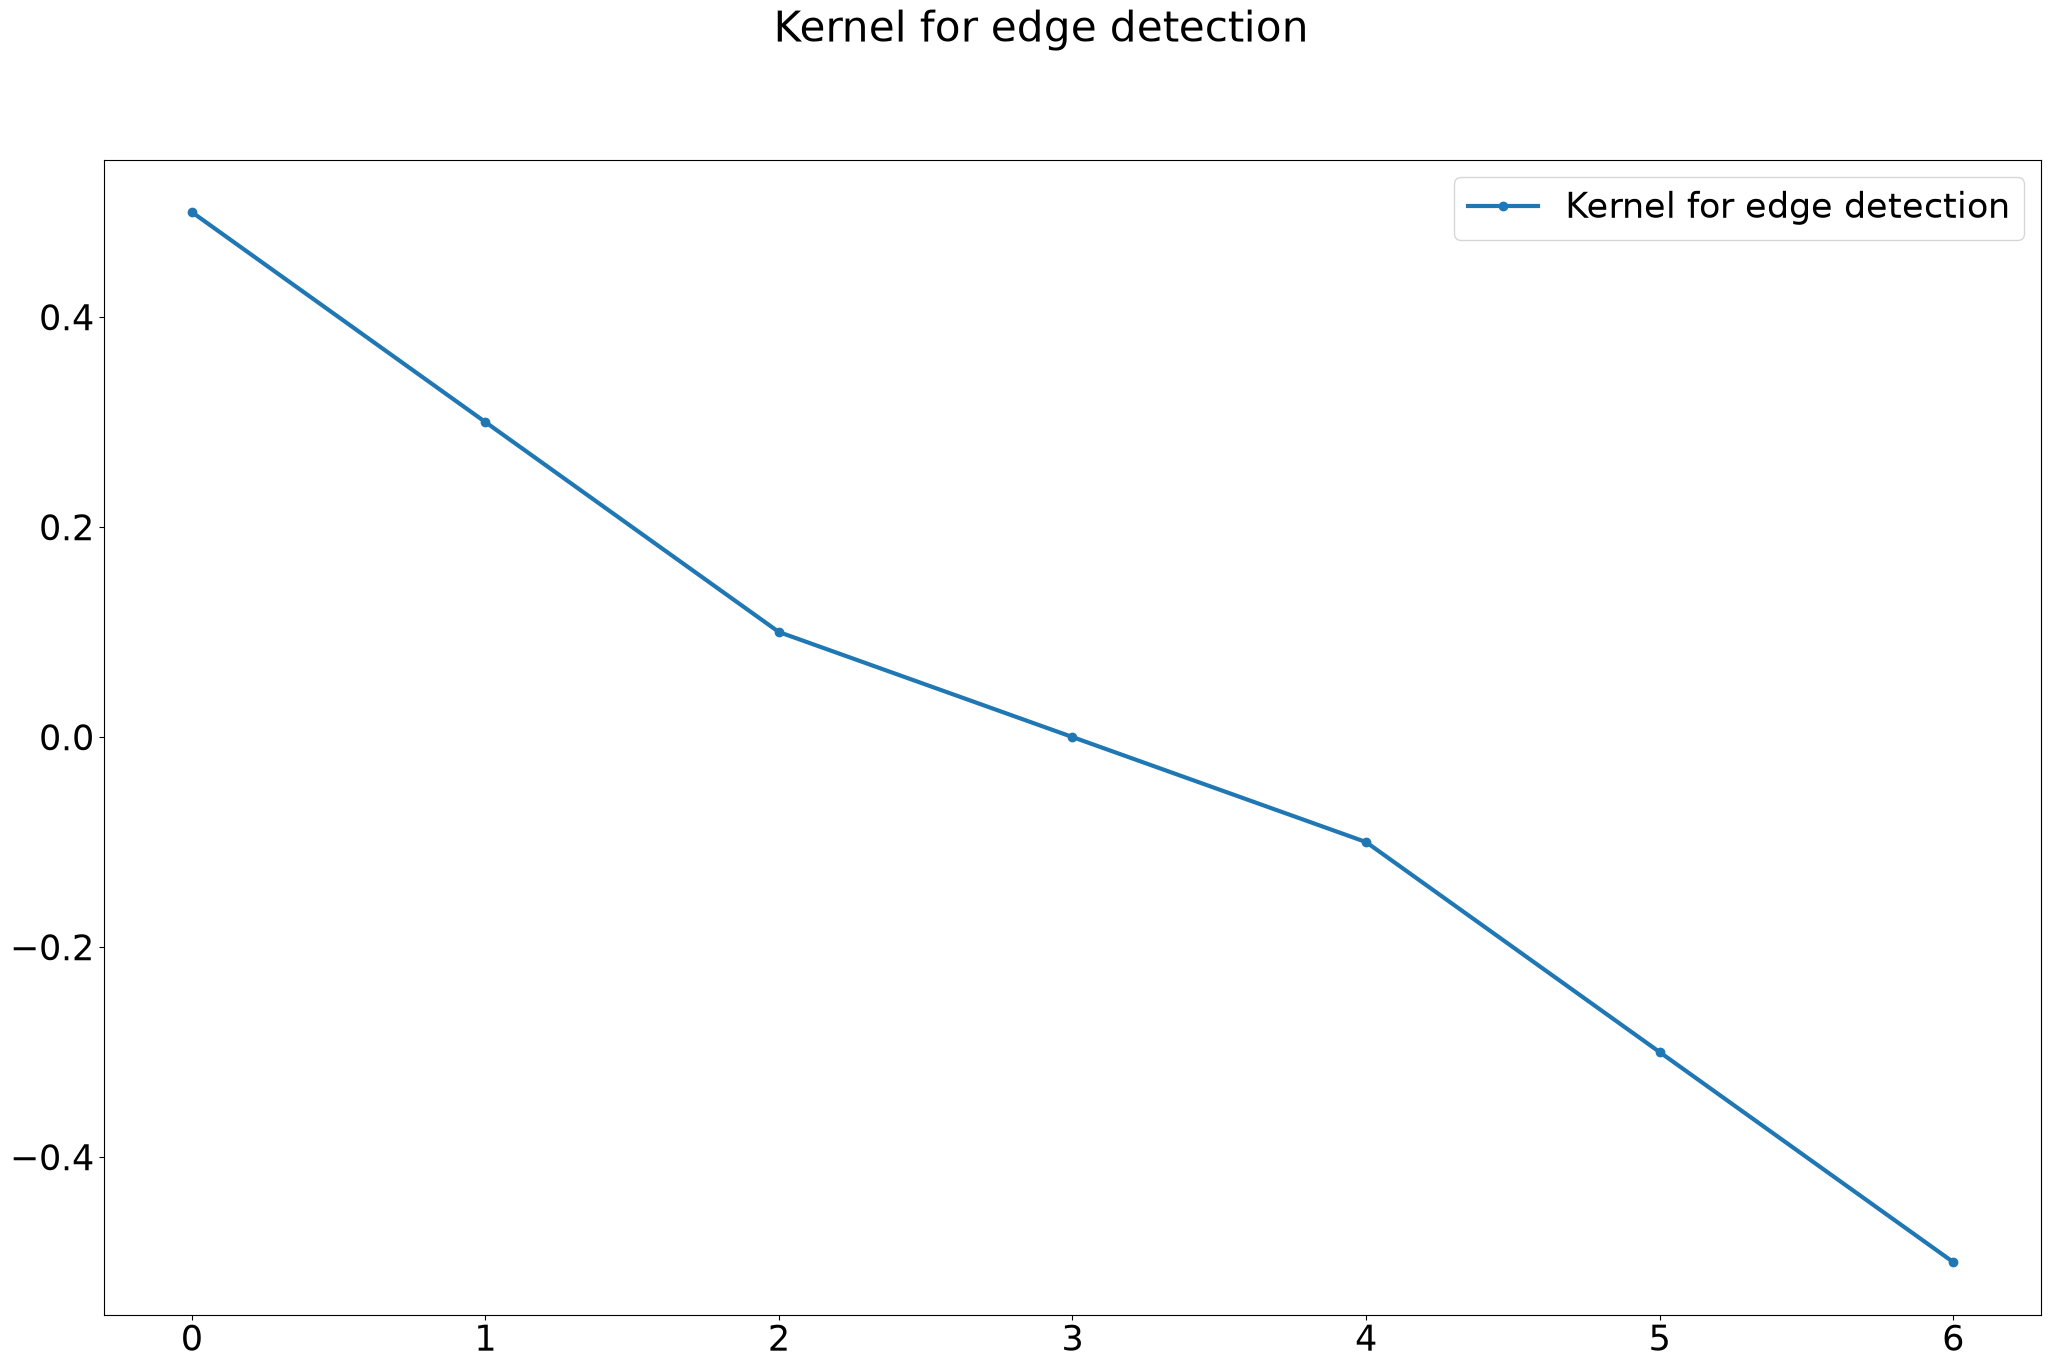

In [22]:
# Plotting the kernel 

plt.figure(figsize=(25,15))
plt.suptitle("Kernel for edge detection", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.plot(kernel, 'o-', linewidth=3, label='Kernel for edge detection')

plt.legend(fontsize = 25)
plt.show()

In [24]:
# Performing edge detection by convolution

filt_signal = np.convolve(newSig, kernel, mode='same')
filt_signal

array([ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0.5,  0.8,  0.9,  0.9,  0.8,  0.5,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0.5,
       -0.8, -0.9, -0.9, -0.8, -0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.5,  0.8,  0.9,  0.9,
        0.8,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. , -0.5, -0.8, -0.9, -0.9, -0.8, -0.5,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

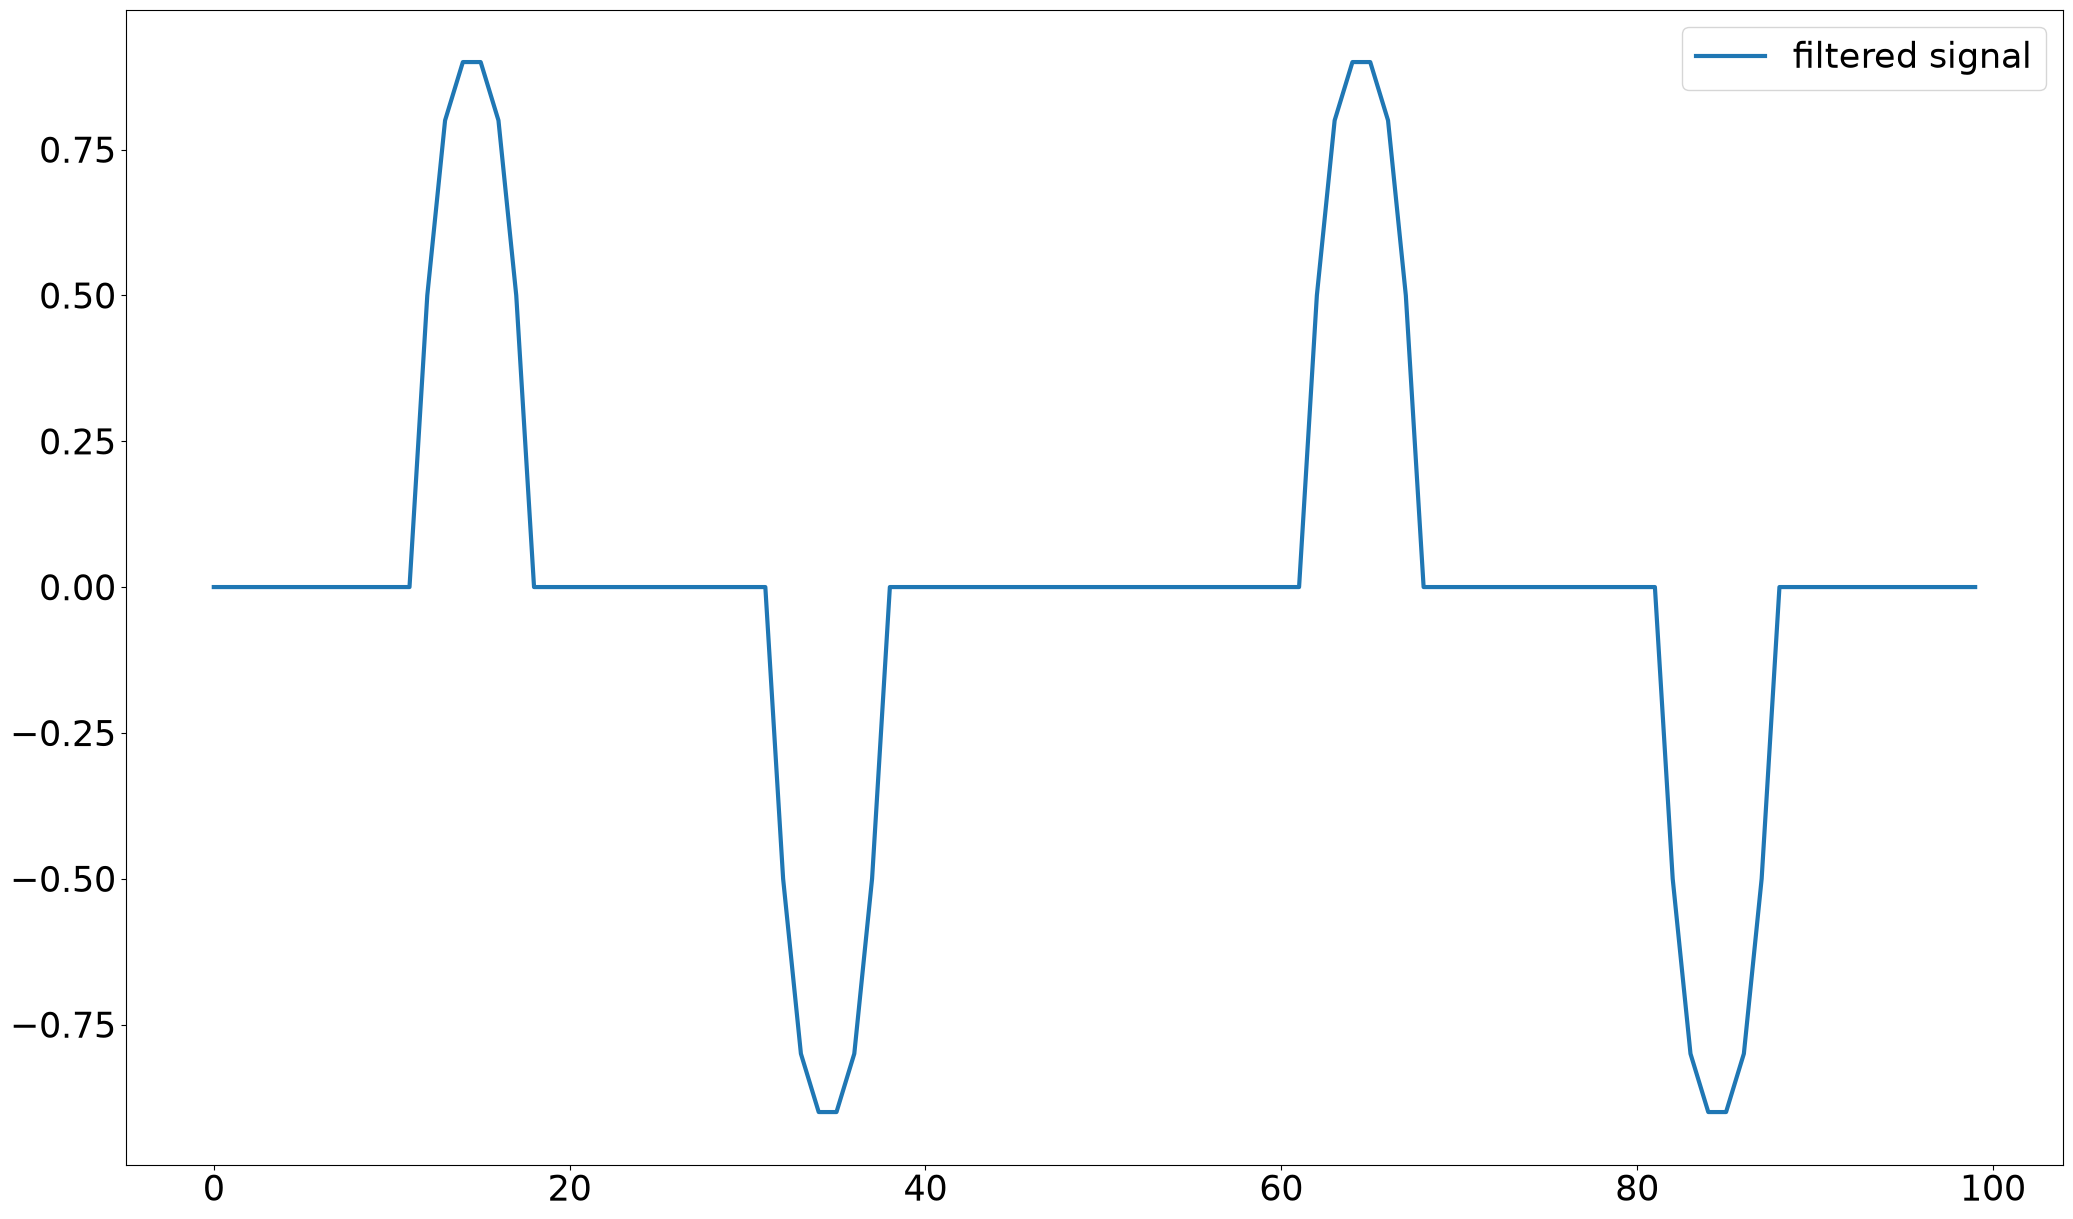

In [25]:
# Plotting filtered signal

plt.figure(figsize=(25,15))
plt.plot(filt_signal, linewidth=3, label='filtered signal')
plt.legend(fontsize = 25)
plt.show()

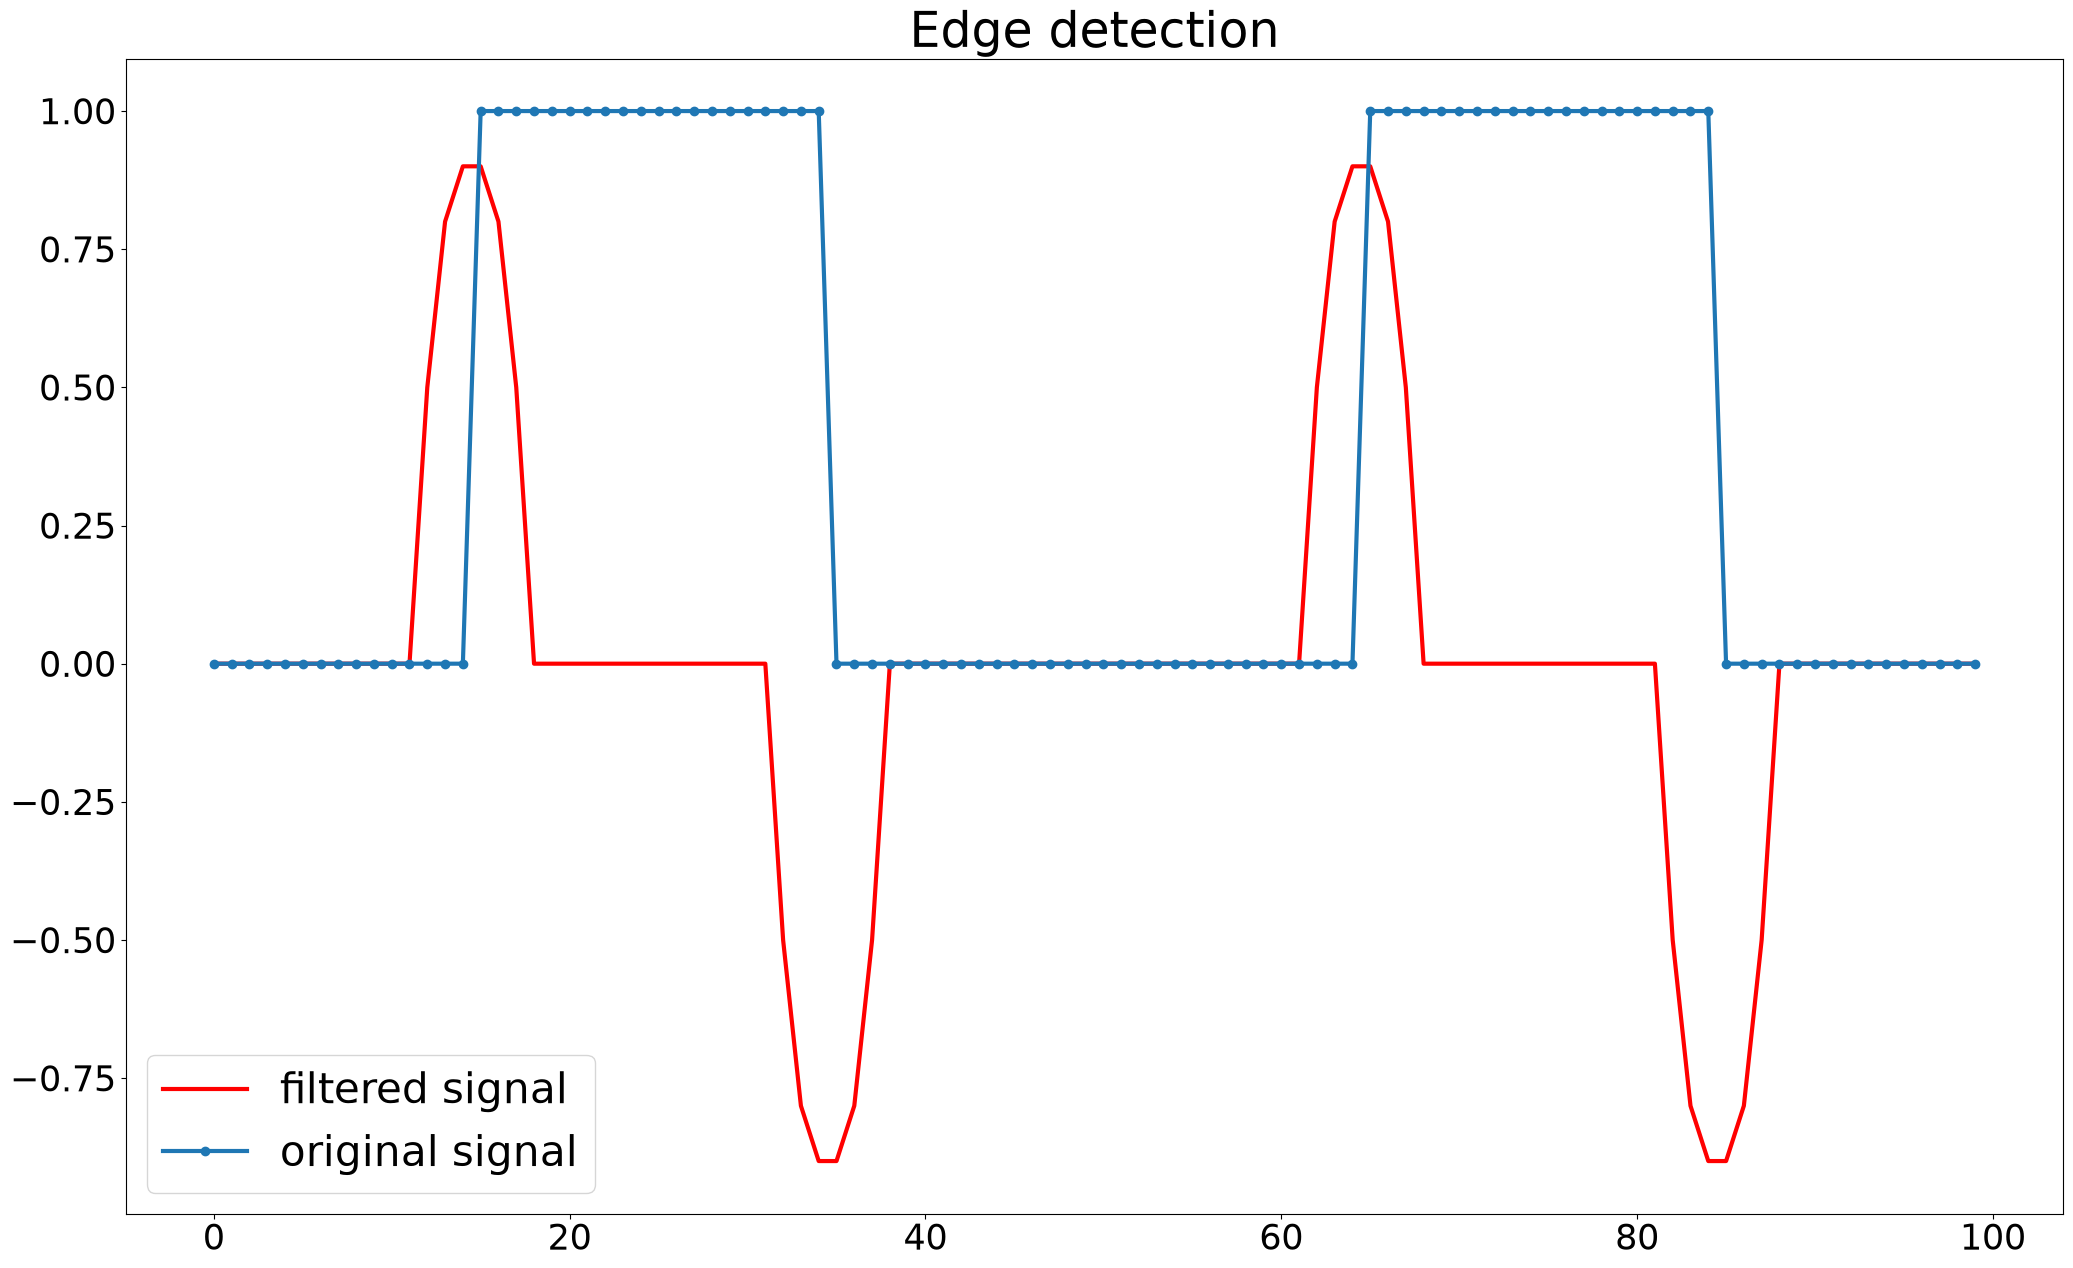

In [34]:
# Plotting filtered signal and original signal

plt.figure(figsize=(25,15))
plt.plot(filt_signal, 'r-', linewidth=3, label='filtered signal')
plt.plot(newSig, 'o-', linewidth=3, label='original signal')
plt.title('Edge detection', fontsize = 35)
plt.legend(fontsize = 30)
plt.show()

# The Convolution theorem 

The convolution of the signals in time domain is equal to the point-wise multiplication of the signals in frequency domain.

In [35]:
sig = np.array([1, 2, 2, 1, 1])
ker = np.array([3, 2, 1])

## Convolution in time domain

In [37]:
Time_dom = np.convolve(sig, ker)
Time_dom

array([ 3,  8, 11,  9,  7,  3,  1])

### Convolution pattern 


In [42]:
# Convolution pattern:  konwolucja = len(sig) + len(ker) - 1
nsig = len(sig)
nker = len(ker)
próbki_konwolucja = nsig + nker - 1
print(f"Sygnał ma: {próbki_konwolucja} próbek")

Sygnał ma: 7 próbek


(764, 1512, 4) float32


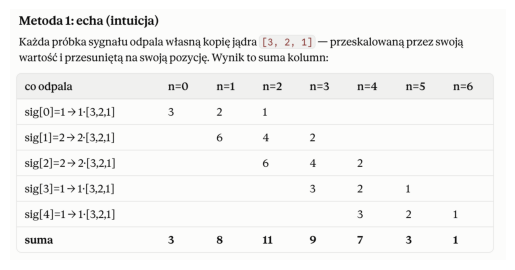

In [46]:
# Jak się liczy konwolucja SPLOT
img = plt.imread("convolution.png")  
print(img.shape, img.dtype)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [47]:
# Different modes 

np.convolve(sig, ker)            # [ 3  8 11  9  7  3  1]  — tryb 'full' (domyślny)
np.convolve(sig, ker, 'same')    # [ 8 11  9  7  3]        — środek, długość jak sig
np.convolve(sig, ker, 'valid')   # [11  9  7]              — tylko pełne nakładki

array([11,  9,  7])

## Convolution in  frequency domain

In [48]:
import scipy

In [53]:
nconv = nsig + nker - 1
sigF = scipy.fft.fft(sig, nconv)
kerF = scipy.fft.fft(ker, nconv)


In [55]:
# Element-wise multiplication of signal and kernel 

sigFFT = sigF * kerF

#Inverse FFT 
Freq_dom = np.real(scipy.fft.ifft(sigFFT))
Freq_dom

array([ 3.,  8., 11.,  9.,  7.,  3.,  1.])

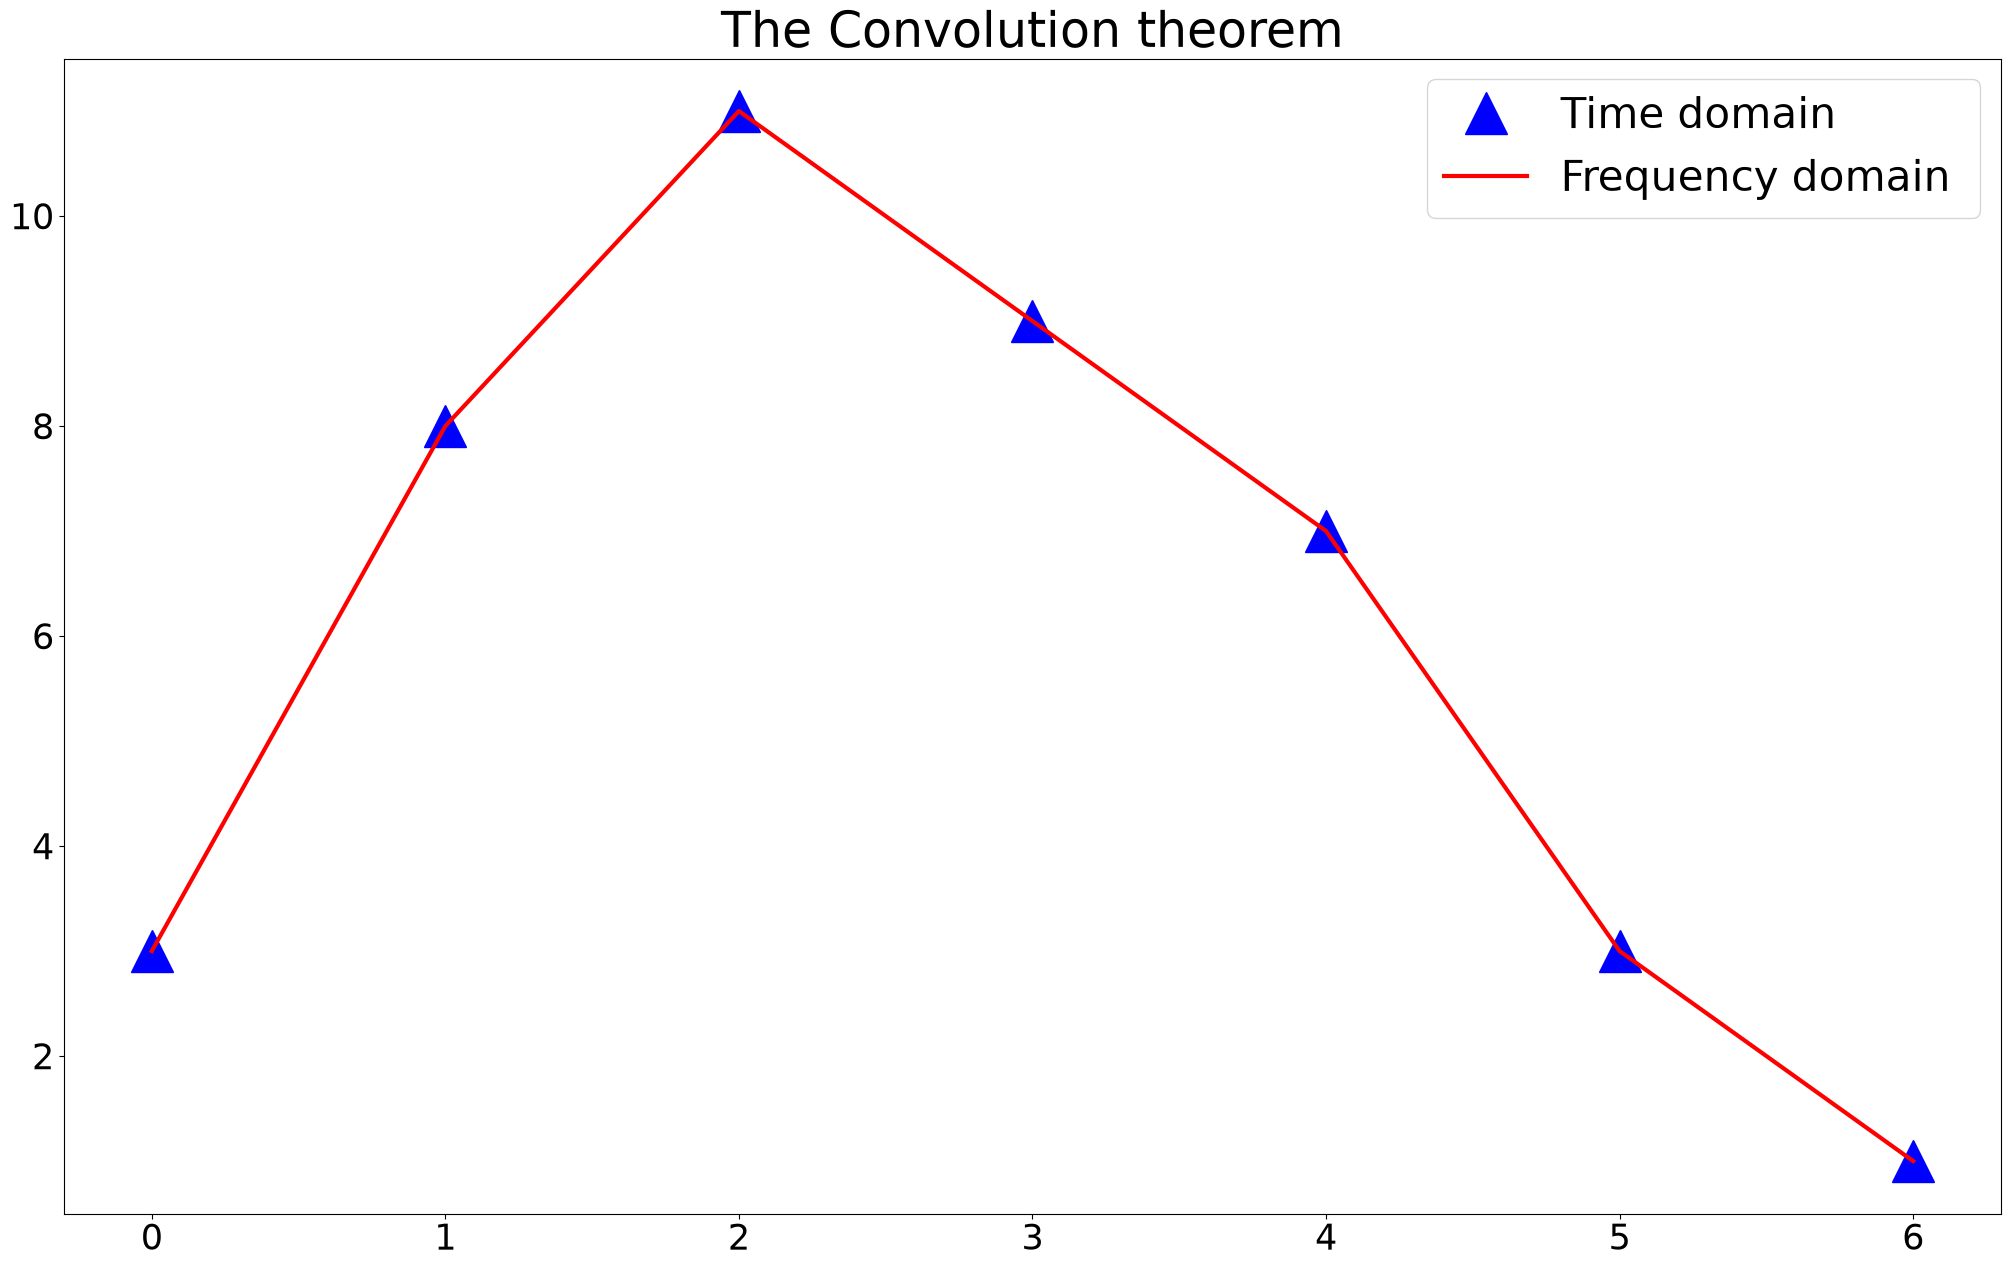

In [62]:
# Plotting time domain and frequency domain

plt.figure(figsize=(25,15))
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25

plt.plot(Time_dom, 'b^', markersize=30, label='Time domain')
plt.plot(Freq_dom, 'r-', linewidth=3, label='Frequency domain ')
plt.title('The Convolution theorem', fontsize = 35)
plt.legend(fontsize = 30)
plt.show()